# Auto-Encoding Variational Bayes (AEVB)

This notebook implements the algorithm proposed in:

**Diederik P. Kingma and Max Welling, "Auto-Encoding Variational Bayes"**

The goal is to implement a Variational Autoencoder (VAE) following the core AEVB/SGVB procedure described in the paper.

We will progressively implement:

1. Data preprocessing
2. Probabilistic encoder
3. Reparameterization trick
4. Probabilistic decoder
5. Variational lower bound (ELBO)
6. Minibatch stochastic-gradient training
7. Evaluation and visualization
8. Experimental reproduction

For the initial implementation, we use the MNIST dataset. The paper models binary MNIST observations using a Bernoulli decoder and uses minibatch stochastic optimization with one latent sample per datapoint.

## 1. Import Required Libraries

The following cell imports TensorFlow for building and training the neural networks, along with NumPy and Matplotlib for numerical operations and visualization.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: []


## 2. Set Random Seeds

AEVB uses stochastic sampling during training. Setting random seeds makes the experiment more reproducible by controlling the random initialization and sampling operations.

In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Load the MNIST Dataset

MNIST contains handwritten digit images.

The original AEVB experiments include MNIST and model the binary image observations using a Bernoulli likelihood. We therefore normalize the pixel values to the range [0, 1], which will later allow the decoder to output Bernoulli probabilities.

For the initial Colab implementation, we use the complete MNIST dataset because its size is small enough for practical training.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 4. Preprocess the Images

Each MNIST image is originally represented as a 28 × 28 array with pixel values from 0 to 255.

We convert the pixels to floating-point values in [0, 1] and flatten each image into a 784-dimensional vector.

The resulting representation is:

x ∈ [0, 1]^784

This representation will be used as the input to the encoder and as the target for the decoder.

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Pixel range: 0.0 to 1.0


## 5. Create Minibatches

The AEVB algorithm is trained using stochastic gradients computed from minibatches rather than the entire dataset.

The paper uses a minibatch size of M = 100 in its experiments. We use the same minibatch size here.

The dataset is shuffled before each epoch so that each minibatch contains a different combination of training examples.

In [6]:
BATCH_SIZE = 100

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size=len(x_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(x_test)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Batch size:", BATCH_SIZE)

Batch size: 100


## 6. Visualize Sample Images

Before implementing the VAE, we verify that the preprocessing pipeline has preserved the MNIST images correctly.

The images are displayed after normalization and reshaping.

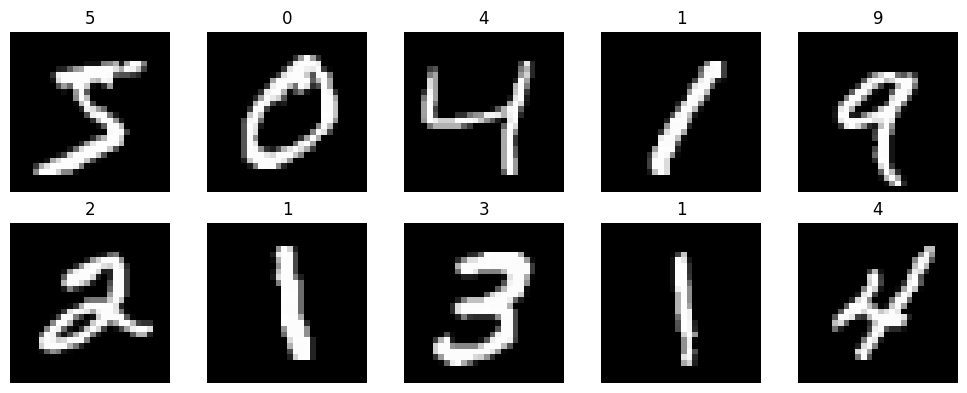

In [7]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title(str(y_train[i]))

plt.tight_layout()
plt.show()

## 7. Define Model Configuration

The main AEVB MNIST experiment uses multilayer perceptrons with 500 hidden units.

We use:

- Input dimension: 784
- Hidden dimension: 500
- Latent dimension: 20
- Batch size: 100
- One latent sample per datapoint

The latent dimension is kept moderate so that training remains lightweight in Google Colab while providing enough capacity for reconstruction.

In [8]:
INPUT_DIM = 784
HIDDEN_DIM = 500
LATENT_DIM = 20

BATCH_SIZE = 100

# One Monte Carlo sample per datapoint, matching the paper's main experiments
NUM_SAMPLES = 1

print("Input dimension :", INPUT_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Latent dimension:", LATENT_DIM)
print("Batch size      :", BATCH_SIZE)
print("Latent samples  :", NUM_SAMPLES)

Input dimension : 784
Hidden dimension: 500
Latent dimension: 20
Batch size      : 100
Latent samples  : 1


## 8. Training Configuration

The AEVB algorithm updates the model parameters using stochastic gradients calculated from minibatches.

For the first implementation, we use 20 epochs. This provides a practical training duration for Google Colab while allowing us to verify that the ELBO improves and reconstruction quality increases.

Once the complete implementation is verified, the number of epochs can be increased for a more thorough experiment.

In [9]:
EPOCHS = 20
LEARNING_RATE = 1e-3

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Epochs: 20
Learning rate: 0.001


## 9. Build the Probabilistic Encoder

The encoder, or recognition model, approximates the posterior distribution q(z|x).

Instead of producing a single latent vector, the encoder produces the parameters of a Gaussian distribution:

- μ: mean of the approximate posterior
- log(σ²): logarithm of the variance

The approximate posterior is therefore:

q(z|x) = N(z; μ(x), diag(σ²(x)))

The encoder uses an MLP with one hidden layer of 500 units.

In [10]:
encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(
        HIDDEN_DIM,
        activation="tanh"
    ),
])

# Separate output layers for the parameters of q(z|x)
encoder_mu = tf.keras.layers.Dense(LATENT_DIM)
encoder_log_var = tf.keras.layers.Dense(LATENT_DIM)

print(encoder.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,500 (1.50 MB)

 Trainable params: 392,500 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

None


## 10. Encode an Input Batch

The encoder transforms each input x into the parameters μ and log(σ²) of its approximate posterior distribution q(z|x).

These parameters will later be used by the reparameterization trick to sample a differentiable latent variable z.

In [11]:
# Take one minibatch
x_batch = next(iter(train_dataset))

# Forward pass through encoder
h = encoder(x_batch)

mu = encoder_mu(h)
log_var = encoder_log_var(h)

print("Input shape :", x_batch.shape)
print("Hidden shape:", h.shape)
print("μ shape     :", mu.shape)
print("log(σ²) shape:", log_var.shape)

Input shape : (100, 784)
Hidden shape: (100, 500)
μ shape     : (100, 20)
log(σ²) shape: (100, 20)


## 11. Verify the Encoder Outputs

Each input image is now represented by a 20-dimensional Gaussian distribution.

For every image, the encoder produces:

- 20 mean values
- 20 log-variance values

No latent sampling is performed yet. Sampling will be implemented in the next level using the reparameterization trick described in the AEVB paper.

In [13]:
print("First image μ:")
print(mu[0].numpy())

print("\nFirst image log(σ²):")
print(log_var[0].numpy())

First image μ:
[-0.6481024   0.3930244   0.5341303  -1.4967402   0.03138196  0.29445413
 -0.11886215  0.3327751  -0.99862826 -0.35440016 -0.1390836  -0.3658024
  1.1276935   0.11927775  0.347861   -1.3749447  -0.07407004  1.4155477
  1.141074    1.2843916 ]

First image log(σ²):
[ 0.698922    0.5944036   0.523831    0.3180015  -0.4646347  -0.6123048
 -1.055635   -1.3777087   1.3221377  -1.0829959   0.35582066 -0.6981361
  0.5655414  -0.4347031  -0.28377816  0.65409493 -0.5673536   0.3088165
  0.0437828  -0.01942027]


## 12. Reparameterization Trick

The encoder gives us μ and log(σ²), but directly sampling

z ~ N(μ, σ²)

would prevent gradients from flowing through the sampling operation.

The reparameterization trick separates the randomness from the learned parameters:

z = μ + σ ⊙ ε

where:

ε ~ N(0, I)

and

σ = exp(0.5 × log(σ²))

This allows gradients to propagate through μ and σ during training.

In [14]:
def reparameterize(mu, log_var):
    """
    Sample z using the reparameterization trick.

    z = mu + sigma * epsilon
    epsilon ~ N(0, I)
    """
    epsilon = tf.random.normal(shape=tf.shape(mu))
    sigma = tf.exp(0.5 * log_var)

    z = mu + sigma * epsilon

    return z

## 13. Sample the Latent Representation

Using the μ and log(σ²) produced by the encoder, we now generate a stochastic latent representation z for each input image.

The same encoder parameters are used for every sample; only ε provides the random variation.

In [15]:
z = reparameterize(mu, log_var)

print("μ shape     :", mu.shape)
print("log(σ²) shape:", log_var.shape)
print("z shape     :", z.shape)

print("\nFirst image latent vector:")
print(z[0].numpy())

μ shape     : (100, 20)
log(σ²) shape: (100, 20)
z shape     : (100, 20)

First image latent vector:
[-0.18365291 -0.7412232   0.9492077  -3.146868   -1.8616201  -0.47071752
 -0.44762212  0.6037895   2.2929363  -0.18627492 -1.9390597  -0.55239964
  0.33529615 -1.4233217  -0.19050688 -0.1955496  -0.37982818 -2.1155095
  2.0669692   1.5800664 ]


## 14. Verify the Stochastic Sampling

Because ε is sampled randomly, repeated calls to the reparameterization function produce different z values while using the same μ and log(σ²).

This stochastic latent sampling is essential to the AEVB algorithm.

In [16]:
z1 = reparameterize(mu, log_var)
z2 = reparameterize(mu, log_var)

difference = tf.reduce_mean(tf.abs(z1 - z2))

print("Mean absolute difference between two samples:", difference.numpy())

Mean absolute difference between two samples: 1.1753759


## 15. Build the Probabilistic Decoder

The decoder models the conditional distribution p(x|z).

For MNIST, the paper uses a Bernoulli distribution for the observed pixels. Therefore, the decoder outputs one probability for each of the 784 pixels.

The decoder architecture is an MLP with:

- 20-dimensional latent input
- 500 hidden units
- 784-dimensional output
- Sigmoid activation on the output

The sigmoid output represents the probability of each pixel being active.

In [17]:
decoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LATENT_DIM,)),
    tf.keras.layers.Dense(
        HIDDEN_DIM,
        activation="tanh"
    ),
    tf.keras.layers.Dense(
        INPUT_DIM,
        activation="sigmoid"
    )
])

print(decoder.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │        10,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       392,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,284 (1.54 MB)

 Trainable params: 403,284 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

None


## 16. Decode a Latent Sample

The sampled latent representation z is passed through the decoder.

The output is a 784-dimensional vector containing the Bernoulli probability of each pixel.

In [18]:
x_reconstructed = decoder(z)

print("Latent shape     :", z.shape)
print("Decoder output   :", x_reconstructed.shape)
print("Output range     :",
      float(tf.reduce_min(x_reconstructed)),
      "to",
      float(tf.reduce_max(x_reconstructed)))

Latent shape     : (100, 20)
Decoder output   : (100, 784)
Output range     : 0.21252262592315674 to 0.8033404350280762


## 17. Visualize a Decoder Output

The decoder currently has randomly initialized parameters, so its reconstruction will not resemble the original digit yet.

This visualization only verifies that the decoder output can be reshaped back into a 28 × 28 image.

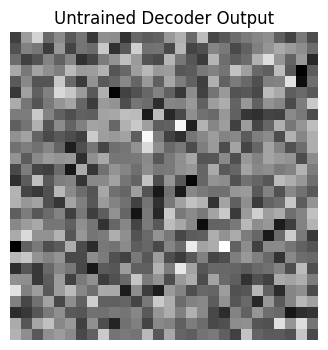

In [19]:
plt.figure(figsize=(4, 4))

plt.imshow(
    x_reconstructed[0].numpy().reshape(28, 28),
    cmap="gray"
)

plt.axis("off")
plt.title("Untrained Decoder Output")
plt.show()

## 18. KL Divergence

The first term of the ELBO measures how different the encoder distribution

q(z|x) = N(μ, σ²I)

is from the prior

p(z) = N(0, I).

For these two diagonal Gaussian distributions, the paper provides the following analytic expression:

-D_KL(q||p)
= 1/2 Σ_j [1 + log(σ_j²) - μ_j² - σ_j²]

Using log(σ²) directly avoids having to explicitly predict σ².

In [20]:
def kl_divergence(mu, log_var):
    """
    Compute KL divergence:

    D_KL(q(z|x) || p(z))

    where:
        q = N(mu, diag(sigma^2))
        p = N(0, I)
    """
    kl = 0.5 * (
        tf.exp(log_var)
        + tf.square(mu)
        - 1.0
        - log_var
    )

    # Sum over latent dimensions
    kl = tf.reduce_sum(kl, axis=1)

    return kl

## 19. Bernoulli Reconstruction Log-Likelihood

For MNIST, the decoder represents p(x|z) using Bernoulli distributions.

For each pixel:

log p(x_i|z)
= x_i log(y_i) + (1-x_i) log(1-y_i)

where y is the decoder's sigmoid output.

The reconstruction log-likelihood is summed over all 784 pixels.

In [21]:
def reconstruction_log_likelihood(x, x_reconstructed):
    """
    Compute log p(x|z) for a Bernoulli decoder.
    """
    log_likelihood = (
        x * tf.math.log(x_reconstructed + 1e-7)
        + (1.0 - x) * tf.math.log(1.0 - x_reconstructed + 1e-7)
    )

    # Sum over the 784 pixels
    log_likelihood = tf.reduce_sum(log_likelihood, axis=1)

    return log_likelihood

## 20. Compute the ELBO

The evidence lower bound is:

ELBO = -KL(q(z|x)||p(z)) + E_q[log p(x|z)]

Because we currently use one latent sample per datapoint (L = 1), the expectation is estimated using the sampled reconstruction.

The objective is maximized during training.

In [22]:
def compute_elbo(x, mu, log_var, x_reconstructed):
    """
    Compute the ELBO for a minibatch.
    """
    kl = kl_divergence(mu, log_var)

    reconstruction = reconstruction_log_likelihood(
        x,
        x_reconstructed
    )

    elbo = reconstruction - kl

    return elbo

## 21. Evaluate the Current ELBO

The model has not been trained yet, so this ELBO value is only a baseline.

During training, we will maximize the ELBO, or equivalently minimize its negative:

Loss = -ELBO

In [23]:
elbo = compute_elbo(
    x_batch,
    mu,
    log_var,
    x_reconstructed
)

print("ELBO per example:", elbo.numpy()[:5])
print("Mean ELBO:", tf.reduce_mean(elbo).numpy())

ELBO per example: [-560.3024  -548.2875  -550.65295 -553.47406 -562.346  ]
Mean ELBO: -554.4136


## 22. Define the Training Loss

TensorFlow optimizers minimize an objective.

Since AEVB maximizes the ELBO, we minimize its negative:

Loss = -ELBO

This is the loss that will be differentiated with respect to both the encoder parameters φ and decoder parameters θ.

In [24]:
def vae_loss(x, mu, log_var, x_reconstructed):
    elbo = compute_elbo(
        x,
        mu,
        log_var,
        x_reconstructed
    )

    # We minimize negative ELBO
    return -tf.reduce_mean(elbo)

## 23. Define the Optimizer

AEVB jointly learns the parameters of the encoder (φ) and decoder (θ).

The paper's MNIST experiments use Adagrad with a global step size selected from 0.01, 0.02, and 0.1.

We use Adagrad here to remain consistent with the paper's reported training procedure.

In [25]:
optimizer = tf.keras.optimizers.Adagrad(
    learning_rate=0.01
)

# All trainable parameters from encoder and decoder
trainable_variables = (
    encoder.trainable_variables
    + encoder_mu.trainable_variables
    + encoder_log_var.trainable_variables
    + decoder.trainable_variables
)

print("Number of trainable tensors:", len(trainable_variables))

Number of trainable tensors: 10


## 24. Define One AEVB Training Step

For one minibatch, the training step performs:

1. Encode x to obtain μ and log(σ²).
2. Sample z using the reparameterization trick.
3. Decode z to obtain p(x|z).
4. Compute the negative ELBO.
5. Compute gradients with respect to θ and φ.
6. Update the model parameters.

In [26]:
@tf.function
def train_step(x):
    with tf.GradientTape() as tape:

        # Encoder
        h = encoder(x, training=True)

        mu = encoder_mu(h)
        log_var = encoder_log_var(h)

        # Reparameterization
        z = reparameterize(mu, log_var)

        # Decoder
        x_reconstructed = decoder(z, training=True)

        # Negative ELBO
        loss = vae_loss(
            x,
            mu,
            log_var,
            x_reconstructed
        )

    gradients = tape.gradient(
        loss,
        trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, trainable_variables)
    )

    return loss

## 25. Test One Training Step

Before running the complete training process, we perform one update on a single minibatch.

The loss should be a finite numerical value, confirming that the forward pass, ELBO calculation, gradient computation, and parameter update are all working.

In [27]:
x_batch = next(iter(train_dataset))

loss = train_step(x_batch)

print("Loss after one training step:", loss.numpy())

Loss after one training step: 554.72577


## 26. Train the AEVB Model

We now apply the AEVB training step to every minibatch for multiple epochs.

Each epoch processes the complete MNIST training set using minibatches of 100 examples.

The mean negative ELBO is recorded so that we can monitor whether the model is learning.

In [28]:
history = []

for epoch in range(1, EPOCHS + 1):

    epoch_losses = []

    for x_batch in train_dataset:
        loss = train_step(x_batch)
        epoch_losses.append(loss)

    mean_loss = tf.reduce_mean(epoch_losses).numpy()
    history.append(mean_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"- Negative ELBO: {mean_loss:.2f}"
    )

Epoch 01/20 - Negative ELBO: 166.42
Epoch 02/20 - Negative ELBO: 135.84
Epoch 03/20 - Negative ELBO: 129.98
Epoch 04/20 - Negative ELBO: 127.71
Epoch 05/20 - Negative ELBO: 126.01
Epoch 06/20 - Negative ELBO: 124.56
Epoch 07/20 - Negative ELBO: 123.45
Epoch 08/20 - Negative ELBO: 122.57
Epoch 09/20 - Negative ELBO: 121.77
Epoch 10/20 - Negative ELBO: 121.06
Epoch 11/20 - Negative ELBO: 120.43
Epoch 12/20 - Negative ELBO: 119.78
Epoch 13/20 - Negative ELBO: 119.19
Epoch 14/20 - Negative ELBO: 118.64
Epoch 15/20 - Negative ELBO: 118.13
Epoch 16/20 - Negative ELBO: 117.67
Epoch 17/20 - Negative ELBO: 117.20
Epoch 18/20 - Negative ELBO: 116.74
Epoch 19/20 - Negative ELBO: 116.35
Epoch 20/20 - Negative ELBO: 115.93


## 27. Plot the Training Objective

The training objective is the negative ELBO.

Because the optimizer minimizes this quantity, we generally expect the negative ELBO to decrease during training.

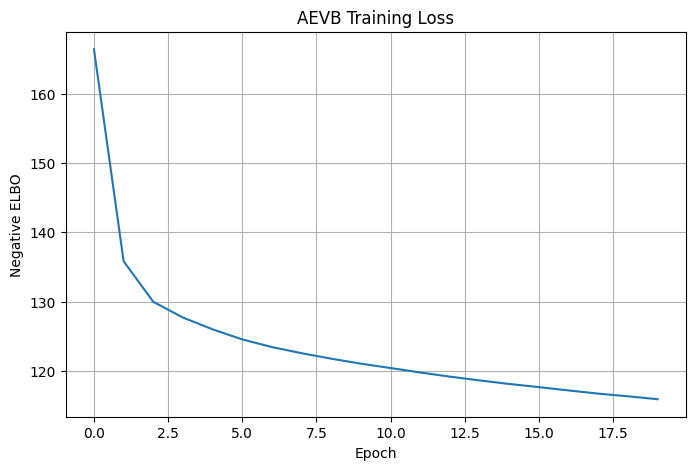

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history)

plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.title("AEVB Training Loss")
plt.grid(True)

plt.show()

## 28. Check the Trained Model

We now run the trained encoder and decoder on a batch of test images.

The resulting reconstructions will be evaluated visually in the next level.

In [30]:
x_test_batch = next(iter(test_dataset))

# Encode
h = encoder(x_test_batch, training=False)
mu = encoder_mu(h)
log_var = encoder_log_var(h)

# Sample
z = reparameterize(mu, log_var)

# Decode
x_reconstructed = decoder(z, training=False)

print("Input shape       :", x_test_batch.shape)
print("Latent shape      :", z.shape)
print("Reconstruction shape:", x_reconstructed.shape)

Input shape       : (100, 784)
Latent shape      : (100, 20)
Reconstruction shape: (100, 784)


## 29. Evaluate the Model on the Test Set

After training, we evaluate the model on previously unseen MNIST images.

For each test minibatch, we:

1. Encode the images.
2. Sample a latent representation.
3. Decode the latent representation.
4. Compute the negative ELBO.

The mean test negative ELBO provides a quantitative measure of how well the trained model explains unseen data.

In [31]:
test_losses = []

for x_batch in test_dataset:

    # Encoder
    h = encoder(x_batch, training=False)
    mu = encoder_mu(h)
    log_var = encoder_log_var(h)

    # Reparameterization
    z = reparameterize(mu, log_var)

    # Decoder
    x_reconstructed = decoder(z, training=False)

    # Negative ELBO
    loss = vae_loss(
        x_batch,
        mu,
        log_var,
        x_reconstructed
    )

    test_losses.append(loss)

test_loss = tf.reduce_mean(test_losses).numpy()

print(f"Test Negative ELBO: {test_loss:.2f}")

Test Negative ELBO: 114.74


## 30. Separate the ELBO Components

The ELBO consists of two terms:

ELBO = Reconstruction Log-Likelihood - KL Divergence

We calculate both terms separately to understand what the trained model has learned.

The reconstruction term measures how well the decoder explains the observed image.

The KL term measures how closely the learned latent distribution stays to the prior N(0, I).

In [32]:
kl_values = []
reconstruction_values = []

for x_batch in test_dataset:

    h = encoder(x_batch, training=False)
    mu = encoder_mu(h)
    log_var = encoder_log_var(h)

    z = reparameterize(mu, log_var)

    x_reconstructed = decoder(z, training=False)

    kl = kl_divergence(mu, log_var)
    reconstruction = reconstruction_log_likelihood(
        x_batch,
        x_reconstructed
    )

    kl_values.append(tf.reduce_mean(kl))
    reconstruction_values.append(
        tf.reduce_mean(reconstruction)
    )

mean_kl = tf.reduce_mean(kl_values).numpy()
mean_reconstruction = tf.reduce_mean(
    reconstruction_values
).numpy()

print(f"Mean KL divergence       : {mean_kl:.2f}")
print(f"Mean reconstruction term : {mean_reconstruction:.2f}")
print(f"ELBO                     : {mean_reconstruction - mean_kl:.2f}")

Mean KL divergence       : 26.14
Mean reconstruction term : -88.61
ELBO                     : -114.75


## 31. Visualize Reconstructions

A quantitative ELBO value does not show what the model actually reconstructs.

We therefore compare the original MNIST images with their reconstructions.

The reconstruction is produced by passing the sampled latent representation through the decoder.

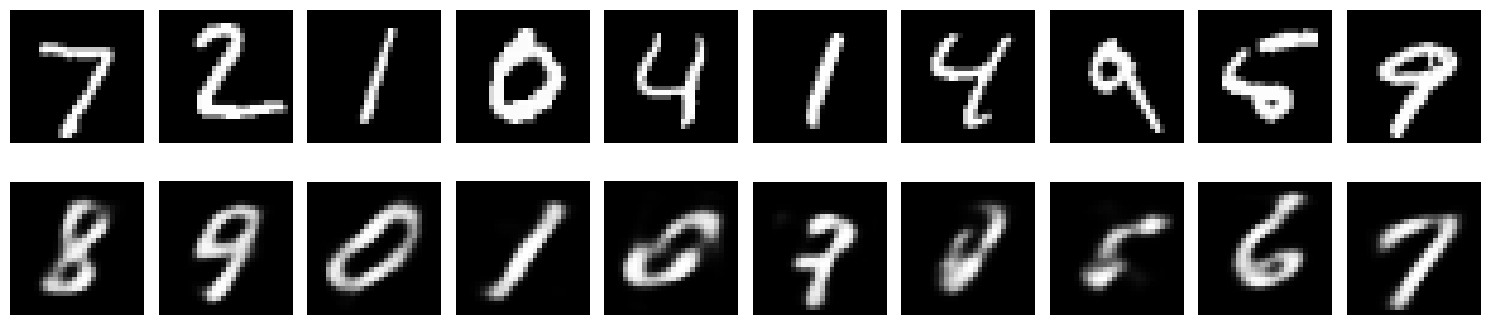

In [33]:
n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(
        x_test_batch[i].numpy().reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, n, n + i + 1)
    plt.imshow(
        x_reconstructed[i].numpy().reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 32. Compare Original and Reconstructed Images

The first row contains the original test images.

The second row contains the corresponding images reconstructed by the decoder.

Successful training should produce reconstructions that preserve the main structure of the original digits, although some details may be lost because the images are represented through a lower-dimensional latent space.

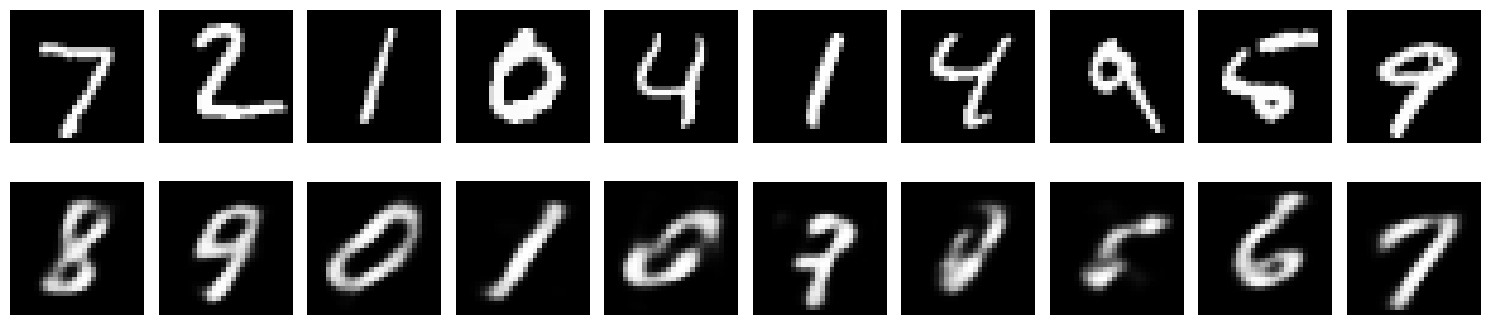

In [35]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    axes[0, i].imshow(
        x_test_batch[i].numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        x_reconstructed[i].numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

## 33. Evaluate Reconstruction Error

For an additional reconstruction metric, we calculate the mean squared error (MSE) between the original images and their reconstructions.

MSE is not the training objective used by the paper for binary MNIST; it is included here only as an intuitive reconstruction-quality metric.

In [36]:
mse = tf.reduce_mean(
    tf.square(
        x_test_batch - x_reconstructed
    )
)

print(f"Reconstruction MSE: {mse.numpy():.6f}")

Reconstruction MSE: 0.115173


## 34. Create a 2D Latent-Space Experiment

Our main VAE uses a 20-dimensional latent representation.

To visualize the latent space, we train a separate VAE with only 2 latent dimensions.

The architecture and AEVB objective remain the same. The only change is:

LATENT_DIM = 2

This allows every MNIST image to be represented as a point (z₁, z₂).

In [37]:
LATENT_DIM_2D = 2

print("2D latent dimension:", LATENT_DIM_2D)

2D latent dimension: 2


## 35. Build the 2D Encoder

The 2D encoder has the same 500-unit hidden layer as the main model, but its output now contains two values for μ and two values for log(σ²).

In [38]:
encoder_2d = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(
        HIDDEN_DIM,
        activation="tanh"
    )
])

encoder_mu_2d = tf.keras.layers.Dense(LATENT_DIM_2D)
encoder_log_var_2d = tf.keras.layers.Dense(LATENT_DIM_2D)

print(encoder_2d.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 500)            │       392,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,500 (1.50 MB)

 Trainable params: 392,500 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

None


## 36. Build the 2D Decoder

The decoder maps the 2-dimensional latent representation back to the 784-dimensional MNIST image.

It uses the same architecture as the original decoder.

In [39]:
decoder_2d = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LATENT_DIM_2D,)),
    tf.keras.layers.Dense(
        HIDDEN_DIM,
        activation="tanh"
    ),
    tf.keras.layers.Dense(
        INPUT_DIM,
        activation="sigmoid"
    )
])

print(decoder_2d.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 500)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       392,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,284 (1.50 MB)

 Trainable params: 394,284 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

None


## 37. Define the 2D AEVB Training Step

The training procedure remains unchanged:

x → encoder → μ, log(σ²) → reparameterization → z → decoder → ELBO

The KL divergence and reconstruction likelihood functions defined earlier can be reused because they do not depend on a fixed latent dimension.

In [40]:
optimizer_2d = tf.keras.optimizers.Adagrad(
    learning_rate=0.01
)

trainable_variables_2d = (
    encoder_2d.trainable_variables
    + encoder_mu_2d.trainable_variables
    + encoder_log_var_2d.trainable_variables
    + decoder_2d.trainable_variables
)


@tf.function
def train_step_2d(x):

    with tf.GradientTape() as tape:

        h = encoder_2d(x, training=True)

        mu = encoder_mu_2d(h)
        log_var = encoder_log_var_2d(h)

        z = reparameterize(mu, log_var)

        x_reconstructed = decoder_2d(
            z,
            training=True
        )

        loss = vae_loss(
            x,
            mu,
            log_var,
            x_reconstructed
        )

    gradients = tape.gradient(
        loss,
        trainable_variables_2d
    )

    optimizer_2d.apply_gradients(
        zip(gradients, trainable_variables_2d)
    )

    return loss

## 38. Train the 2D VAE

The 2D model is used specifically for visualization.

We train it for 15 epochs, which is sufficient for obtaining a useful latent-space structure while keeping the additional Colab computation modest.

In [41]:
EPOCHS_2D = 15

history_2d = []

for epoch in range(1, EPOCHS_2D + 1):

    epoch_losses = []

    for x_batch in train_dataset:
        loss = train_step_2d(x_batch)
        epoch_losses.append(loss)

    mean_loss = tf.reduce_mean(epoch_losses).numpy()
    history_2d.append(mean_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS_2D} "
        f"- Negative ELBO: {mean_loss:.2f}"
    )

Epoch 01/15 - Negative ELBO: 201.35
Epoch 02/15 - Negative ELBO: 183.63
Epoch 03/15 - Negative ELBO: 181.14
Epoch 04/15 - Negative ELBO: 180.09
Epoch 05/15 - Negative ELBO: 179.40
Epoch 06/15 - Negative ELBO: 178.80
Epoch 07/15 - Negative ELBO: 178.14
Epoch 08/15 - Negative ELBO: 177.48
Epoch 09/15 - Negative ELBO: 176.85
Epoch 10/15 - Negative ELBO: 176.26
Epoch 11/15 - Negative ELBO: 175.72
Epoch 12/15 - Negative ELBO: 175.20
Epoch 13/15 - Negative ELBO: 174.67
Epoch 14/15 - Negative ELBO: 174.14
Epoch 15/15 - Negative ELBO: 173.60


## 39. Encode the Test Set into the 2D Latent Space

After training, we use the encoder's mean μ as the deterministic representation of each test image.

Using μ rather than a randomly sampled z gives a stable location for each image in the latent space.

Each image is therefore represented by two coordinates:

(z₁, z₂) = μ(x)

In [42]:
latent_points = []
latent_labels = []

for x_batch, y_batch in tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
).batch(BATCH_SIZE):

    h = encoder_2d(
        x_batch,
        training=False
    )

    mu = encoder_mu_2d(h)

    latent_points.append(mu.numpy())
    latent_labels.append(y_batch.numpy())

latent_points = np.concatenate(latent_points)
latent_labels = np.concatenate(latent_labels)

print("Latent points shape:", latent_points.shape)
print("Labels shape:", latent_labels.shape)

Latent points shape: (10000, 2)
Labels shape: (10000,)


## 40. Visualize the Learned Latent Space

Each point represents one MNIST test image.

Points are colored according to their digit label. Similar digits should tend to occupy related regions of the learned latent space.

This visualization shows how the encoder organizes the data in its 2-dimensional representation.

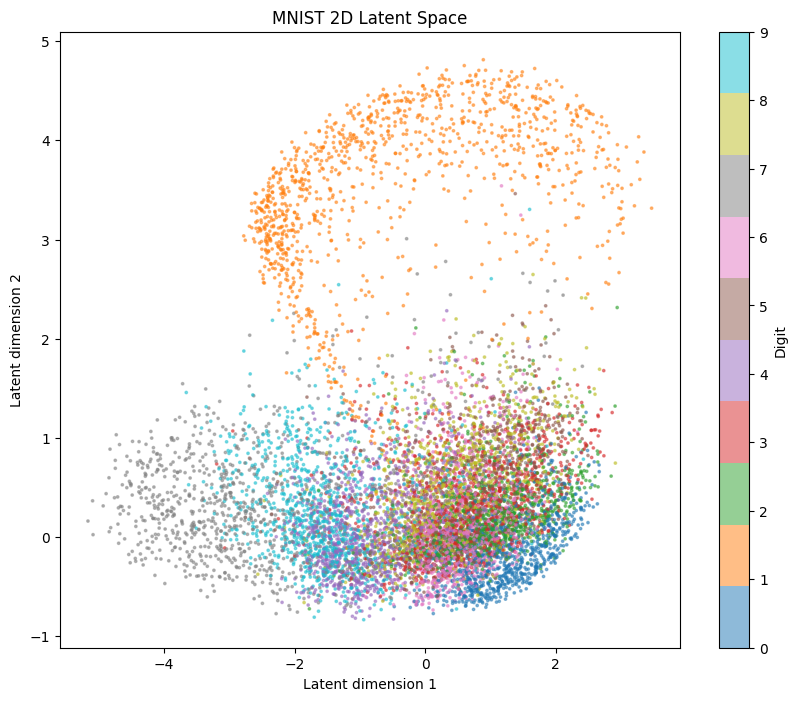

In [43]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=3,
    alpha=0.5
)

plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("MNIST 2D Latent Space")
plt.show()

## 41. Visualize the 2D Training Objective

The negative ELBO should generally decrease during training, indicating that the 2D model is learning to improve the variational lower bound.

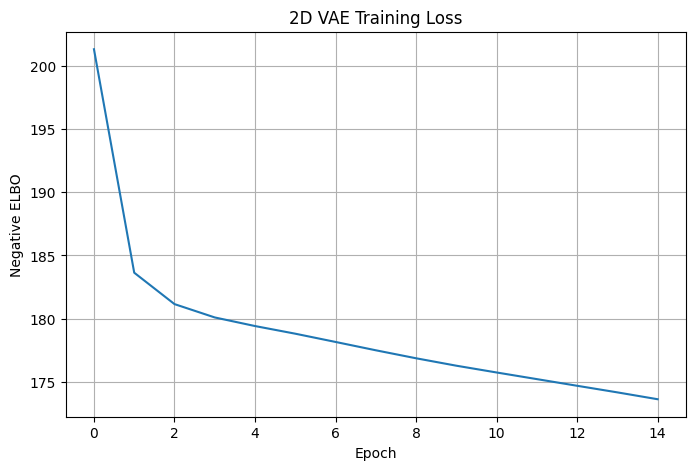

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(history_2d)

plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.title("2D VAE Training Loss")
plt.grid(True)

plt.show()

## 42. Sample Latent Vectors from the Prior

The VAE assumes a standard normal prior over the latent variables:

z ~ N(0, I)

We therefore generate completely new latent vectors without providing the model with any MNIST image.

In [45]:
NUM_GENERATED = 20

z_random = tf.random.normal(
    shape=(NUM_GENERATED, LATENT_DIM)
)

print("Generated latent vectors shape:", z_random.shape)

Generated latent vectors shape: (20, 20)


## 43. Generate Images from Random Latent Vectors

The randomly sampled latent vectors are passed directly to the trained decoder.

The decoder converts each latent vector into 784 Bernoulli probabilities representing a generated MNIST image.

In [46]:
generated_images = decoder(
    z_random,
    training=False
)

print("Generated images shape:", generated_images.shape)

Generated images shape: (20, 784)


## 44. Visualize Generated Images

The generated outputs are reshaped into 28 × 28 images.

Unlike reconstruction, these images do not correspond to any particular input image. They are generated from random samples of the learned latent prior.

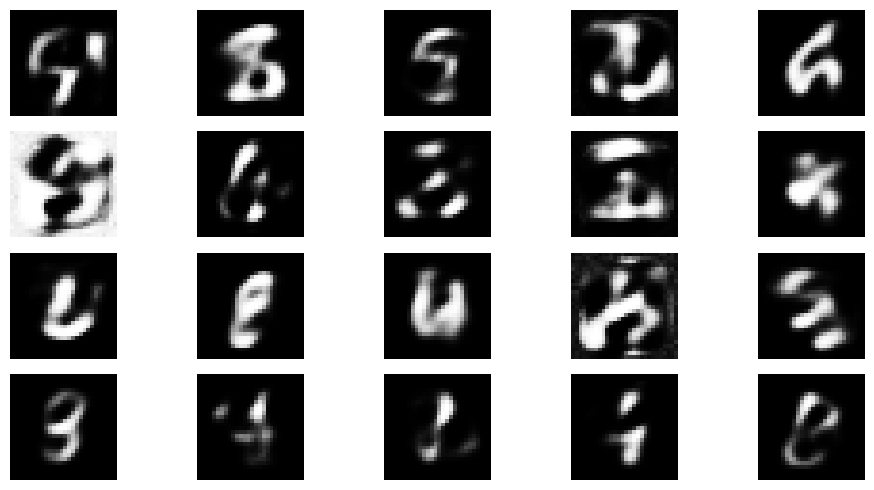

In [47]:
plt.figure(figsize=(10, 5))

for i in range(NUM_GENERATED):
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        generated_images[i].numpy().reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 45. Sample Multiple Images from the Same Latent Region

The latent space is continuous.

To demonstrate this, we select one latent vector and create small perturbations around it. The decoder should produce related images because nearby points in latent space correspond to nearby regions of the learned generative model.

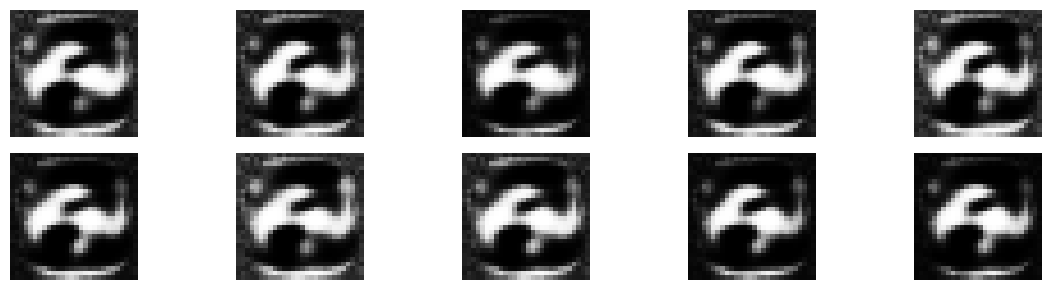

In [48]:
# Start from one random latent vector
z_center = tf.random.normal(
    shape=(1, LATENT_DIM)
)

# Add small perturbations
noise = tf.random.normal(
    shape=(10, LATENT_DIM),
    stddev=0.15
)

z_nearby = z_center + noise

nearby_images = decoder(
    z_nearby,
    training=False
)

plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        nearby_images[i].numpy().reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 46. Generate Images from the 2D Latent Model

The 2D model provides an additional way to explore the learned generative space.

We sample points from the 2D standard normal prior and decode them using the trained 2D decoder.

Each point in the latent space corresponds to a generated image.

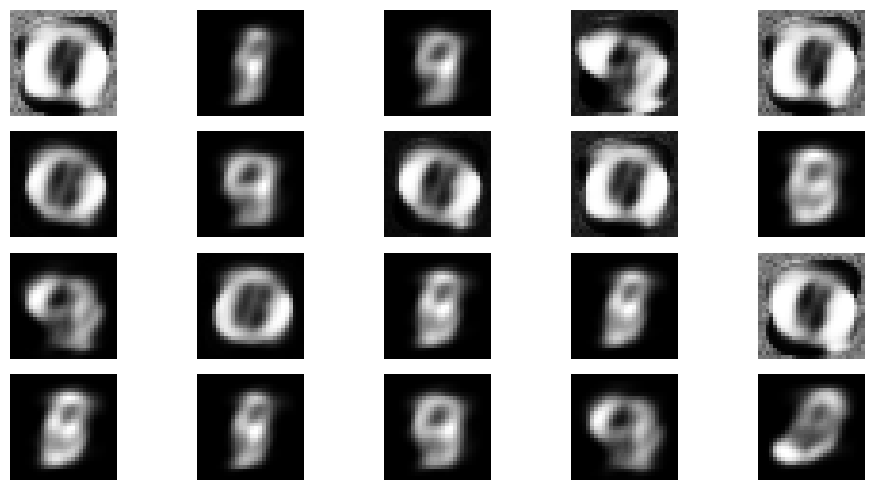

In [49]:
NUM_GENERATED_2D = 20

z_random_2d = tf.random.normal(
    shape=(NUM_GENERATED_2D, 2)
)

generated_images_2d = decoder_2d(
    z_random_2d,
    training=False
)

plt.figure(figsize=(10, 5))

for i in range(NUM_GENERATED_2D):
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        generated_images_2d[i].numpy().reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 47. Marginal Likelihood Evaluation

The marginal likelihood measures how well the learned generative model explains an observed data point:

pθ(x) = ∫ pθ(x,z) dz

For high-dimensional latent spaces this integral is generally intractable.

The paper therefore uses an MCMC-based estimator for very low-dimensional latent spaces. In the MNIST experiment, the authors used 3 latent variables and neural networks with 100 hidden units.

The estimator has three stages:

1. Sample latent variables from the posterior pθ(z|x) using gradient-based MCMC.
2. Fit a density estimator q(z) to those posterior samples.
3. Draw new posterior samples and estimate pθ(x) using the importance-style estimator described in Appendix D.

The paper notes that this estimator becomes unreliable as the latent dimensionality increases beyond roughly 5 dimensions.

## 48. Build a Low-Dimensional Model for Marginal Likelihood Evaluation

The marginal-likelihood experiment uses a separate model from our main 20-dimensional VAE.

Following the paper, we use:

- 100 hidden units
- 3 latent dimensions
- Bernoulli decoder for MNIST
- the same encoder/decoder structure used in the main AEVB implementation

This model is created only for the marginal-likelihood experiment.

In [50]:
MARGINAL_HIDDEN_DIM = 100
MARGINAL_LATENT_DIM = 3

encoder_ml = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(MARGINAL_HIDDEN_DIM, activation="tanh")
])

encoder_mu_ml = tf.keras.layers.Dense(MARGINAL_LATENT_DIM)
encoder_log_var_ml = tf.keras.layers.Dense(MARGINAL_LATENT_DIM)

decoder_ml = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MARGINAL_LATENT_DIM,)),
    tf.keras.layers.Dense(MARGINAL_HIDDEN_DIM, activation="tanh"),
    tf.keras.layers.Dense(INPUT_DIM, activation="sigmoid")
])

optimizer_ml = tf.keras.optimizers.Adagrad(learning_rate=0.01)

trainable_variables_ml = (
    encoder_ml.trainable_variables
    + encoder_mu_ml.trainable_variables
    + encoder_log_var_ml.trainable_variables
    + decoder_ml.trainable_variables
)

## 49. Train the 3D Model

We train this smaller model using the same AEVB objective:

Negative ELBO = KL divergence − reconstruction log likelihood.

The purpose is not to replace the main 20D model. This model exists only because the marginal-likelihood estimator in the paper is intended for very low-dimensional latent spaces.

In [51]:
@tf.function
def train_step_ml(x):
    with tf.GradientTape() as tape:
        h = encoder_ml(x, training=True)
        mu = encoder_mu_ml(h)
        log_var = encoder_log_var_ml(h)

        z = reparameterize(mu, log_var)

        x_reconstructed = decoder_ml(z, training=True)

        loss = vae_loss(
            x,
            mu,
            log_var,
            x_reconstructed
        )

    gradients = tape.gradient(
        loss,
        trainable_variables_ml
    )

    optimizer_ml.apply_gradients(
        zip(gradients, trainable_variables_ml)
    )

    return loss

## 50. Train the Low-Dimensional AEVB Model

The paper used minibatches of 100 datapoints and one latent sample per datapoint.

We retain the same minibatch size and one-sample AEVB estimator here.

In [52]:
EPOCHS_ML = 15

history_ml = []

for epoch in range(1, EPOCHS_ML + 1):

    epoch_losses = []

    for x_batch in train_dataset:
        loss = train_step_ml(x_batch)
        epoch_losses.append(loss)

    mean_loss = tf.reduce_mean(epoch_losses).numpy()
    history_ml.append(mean_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS_ML} "
        f"- Negative ELBO: {mean_loss:.2f}"
    )

Epoch 01/15 - Negative ELBO: 203.20
Epoch 02/15 - Negative ELBO: 182.88
Epoch 03/15 - Negative ELBO: 179.26
Epoch 04/15 - Negative ELBO: 176.90
Epoch 05/15 - Negative ELBO: 174.92
Epoch 06/15 - Negative ELBO: 173.43
Epoch 07/15 - Negative ELBO: 172.26
Epoch 08/15 - Negative ELBO: 171.27
Epoch 09/15 - Negative ELBO: 170.38
Epoch 10/15 - Negative ELBO: 169.55
Epoch 11/15 - Negative ELBO: 168.67
Epoch 12/15 - Negative ELBO: 167.84
Epoch 13/15 - Negative ELBO: 167.02
Epoch 14/15 - Negative ELBO: 166.24
Epoch 15/15 - Negative ELBO: 165.48


## 51. Select an MNIST Test Image

We select one test image for marginal likelihood estimation.

The goal is to estimate how much probability the trained generative model assigns to this particular observation.

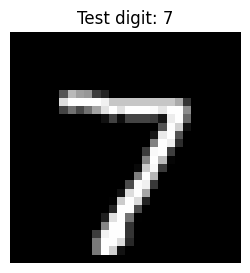

In [53]:
x_ml = tf.convert_to_tensor(
    x_test[0:1],
    dtype=tf.float32
)

plt.figure(figsize=(3, 3))
plt.imshow(x_ml.numpy().reshape(28, 28), cmap="gray")
plt.axis("off")
plt.title(f"Test digit: {y_test[0]}")
plt.show()

## 52. Compute the Posterior Log-Density

For a fixed observation x, the posterior is

pθ(z|x) ∝ pθ(z)pθ(x|z)

Therefore,

log pθ(z|x)
=
log pθ(z)
+
log pθ(x|z)
+
constant

The constant does not depend on z, so it is unnecessary when computing the gradient used by HMC.

In [54]:
def log_posterior(z, x):
    # log p(z), where p(z) = N(0, I)
    log_pz = -0.5 * tf.reduce_sum(
        tf.square(z) + np.log(2.0 * np.pi),
        axis=1
    )

    # log p(x | z), Bernoulli decoder
    x_reconstructed = decoder_ml(z, training=False)

    log_px_given_z = tf.reduce_sum(
        x * tf.math.log(x_reconstructed + 1e-7)
        + (1.0 - x) * tf.math.log(
            1.0 - x_reconstructed + 1e-7
        ),
        axis=1
    )

    return log_pz + log_px_given_z

## 53. Compute ∇z log pθ(z|x)

HMC requires the gradient of the posterior log-density with respect to the latent variable z.

Because the decoder is differentiable, TensorFlow can calculate this gradient automatically.

In [55]:
def posterior_gradient(z, x):
    with tf.GradientTape() as tape:
        tape.watch(z)
        log_prob = log_posterior(z, x)

    gradient = tape.gradient(
        log_prob,
        z
    )

    return gradient

## 54. Initialize the Latent State

We initialize the HMC chain with a random point in the 3-dimensional latent space.

The chain will then move toward regions of high posterior probability pθ(z|x).

In [56]:
z_current = tf.random.normal(
    shape=(1, MARGINAL_LATENT_DIM),
    seed=SEED
)

print("Initial latent state:")
print(z_current.numpy())

Initial latent state:
[[ 1.3148774  -0.15421568  0.9113878 ]]


## 55. Hamiltonian Monte Carlo

The paper uses gradient-based MCMC, specifically Hybrid Monte Carlo (HMC), to sample from the posterior pθ(z|x).

HMC introduces an auxiliary momentum variable and uses leapfrog integration to propose new latent states.

The proposal is accepted or rejected using the Hamiltonian energy difference.

In [58]:
def hmc_step(
    z_current,
    x,
    step_size=0.01,
    leapfrog_steps=4
):
    # Sample momentum
    momentum = tf.random.normal(
        shape=tf.shape(z_current)
    )

    # Initial Hamiltonian
    current_log_prob = log_posterior(
        z_current,
        x
    )

    current_kinetic = 0.5 * tf.reduce_sum(
        tf.square(momentum),
        axis=1
    )

    current_hamiltonian = (
        -current_log_prob
        + current_kinetic
    )

    # Start proposal
    z_proposed = tf.identity(z_current)
    momentum_proposed = tf.identity(momentum)

    # First half momentum update
    grad = posterior_gradient(
        z_proposed,
        x
    )

    momentum_proposed += (
        0.5 * step_size * grad
    )

    # Leapfrog integration
    for _ in range(leapfrog_steps):

        z_proposed += (
            step_size * momentum_proposed
        )

        grad = posterior_gradient(
            z_proposed,
            x
        )

        if _ != leapfrog_steps - 1:
            momentum_proposed += (
                step_size * grad
            )

    # Final half momentum update
    momentum_proposed += (
        0.5 * step_size * grad
    )

    # Negate momentum for reversibility
    momentum_proposed = -momentum_proposed

    # Proposed Hamiltonian
    proposed_log_prob = log_posterior(
        z_proposed,
        x
    )

    proposed_kinetic = 0.5 * tf.reduce_sum(
        tf.square(momentum_proposed),
        axis=1
    )

    proposed_hamiltonian = (
        -proposed_log_prob
        + proposed_kinetic
    )

    # Metropolis acceptance probability
    log_acceptance = (
        current_hamiltonian
        - proposed_hamiltonian
    )

    acceptance_probability = tf.exp(
        tf.minimum(
            log_acceptance,
            0.0
        )
    )

    random_value = tf.random.uniform(
        shape=(1,)
    )

    accepted = (
        random_value < acceptance_probability
    )

    z_next = tf.where(
        accepted,
        z_proposed,
        z_current
    )

    return z_next, accepted, acceptance_probability

## 56. Test One HMC Step

We perform one HMC transition starting from the previously initialized latent state.

A successful transition should produce another point in the 3-dimensional latent space.

In [59]:
z_next, accepted, acceptance_probability = hmc_step(
    z_current,
    x_ml,
    step_size=0.01,
    leapfrog_steps=4
)

print("New latent state:")
print(z_next.numpy())

print("\nAccepted:", bool(accepted.numpy()[0]))
print(
    "Acceptance probability:",
    float(acceptance_probability.numpy()[0])
)

New latent state:
[[ 1.2087977  -0.16665609  0.94686764]]

Accepted: True
Acceptance probability: 0.9963597655296326


## 57. Sample from pθ(z|x)

We now run the HMC chain repeatedly.

The paper's marginal-likelihood experiment used 50 posterior samples for each datapoint with 4 leapfrog steps.

These samples approximate the true posterior distribution pθ(z|x).

In [60]:
NUM_POSTERIOR_SAMPLES = 50
HMC_LEAPFROG_STEPS = 4
HMC_STEP_SIZE = 0.01

z_chain = z_current
posterior_samples = []
acceptances = []

for _ in range(NUM_POSTERIOR_SAMPLES):

    z_chain, accepted, acceptance_probability = hmc_step(
        z_chain,
        x_ml,
        step_size=HMC_STEP_SIZE,
        leapfrog_steps=HMC_LEAPFROG_STEPS
    )

    posterior_samples.append(
        z_chain.numpy()[0]
    )

    acceptances.append(
        bool(accepted.numpy()[0])
    )

posterior_samples = np.array(
    posterior_samples
)

acceptance_rate = np.mean(
    acceptances
)

print(
    "Posterior samples shape:",
    posterior_samples.shape
)

print(
    "HMC acceptance rate:",
    acceptance_rate
)

Posterior samples shape: (50, 3)
HMC acceptance rate: 1.0


## 58. Visualize the Posterior Samples

The HMC samples show the region of the latent space that has high posterior probability for the selected MNIST image.

Because the model has three latent dimensions, we visualize the samples using the first two latent dimensions.

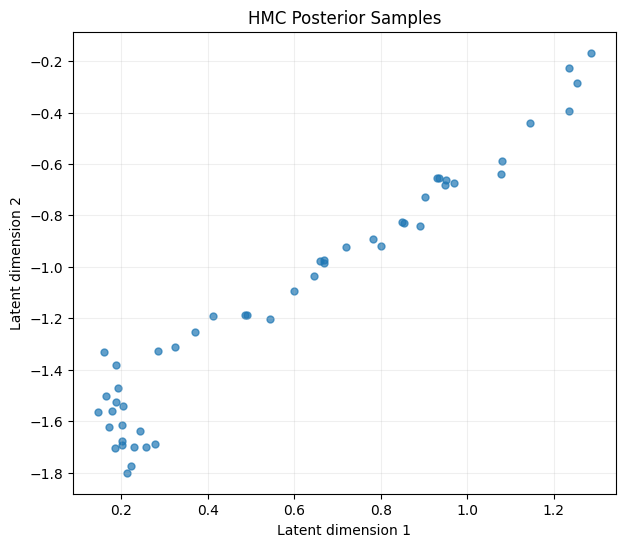

In [61]:
plt.figure(figsize=(7, 6))

plt.scatter(
    posterior_samples[:, 0],
    posterior_samples[:, 1],
    s=25,
    alpha=0.7
)

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("HMC Posterior Samples")
plt.grid(alpha=0.2)

plt.show()

## 59. Fit the Density Estimator q(z)

The paper's marginal-likelihood estimator requires a density estimator q(z) fitted to the first set of posterior samples.

The paper does not prescribe a specific density-estimation method.

Here we use a Gaussian kernel density estimator (KDE) as a practical implementation choice.

The KDE approximates the density of the HMC posterior samples.

In [62]:
from scipy.stats import gaussian_kde

q_density = gaussian_kde(
    posterior_samples.T
)

print("Density estimator fitted.")

Density estimator fitted.


## 60. Draw a Second Set of Posterior Samples

The estimator requires a second set of samples from pθ(z|x).

We therefore continue the HMC chain and collect another 50 posterior samples.

These samples are different from the samples used to fit q(z).

In [63]:
second_posterior_samples = []
second_acceptances = []

for _ in range(NUM_POSTERIOR_SAMPLES):

    z_chain, accepted, acceptance_probability = hmc_step(
        z_chain,
        x_ml,
        step_size=HMC_STEP_SIZE,
        leapfrog_steps=HMC_LEAPFROG_STEPS
    )

    second_posterior_samples.append(
        z_chain.numpy()[0]
    )

    second_acceptances.append(
        bool(accepted.numpy()[0])
    )

second_posterior_samples = np.array(
    second_posterior_samples
)

print(
    "Second posterior samples shape:",
    second_posterior_samples.shape
)

print(
    "Second HMC acceptance rate:",
    np.mean(second_acceptances)
)

Second posterior samples shape: (50, 3)
Second HMC acceptance rate: 1.0


## 61. Compute log p(z)

The prior of the AEVB model is a standard multivariate Gaussian:

p(z) = N(0, I)

Therefore its log-density can be evaluated analytically.

In [65]:
def log_prior_z(z):
    return -0.5 * tf.reduce_sum(
        tf.square(z)
        + np.log(2.0 * np.pi),
        axis=1
    )

## 62. Compute log pθ(x|z)

The decoder uses a Bernoulli distribution for MNIST pixels.

Therefore:

log pθ(x|z)
=
Σ [x log(y) + (1-x) log(1-y)]

where y is the decoder output.

In [66]:
def log_likelihood_x_given_z(x, z):
    x_reconstructed = decoder_ml(
        z,
        training=False
    )

    return tf.reduce_sum(
        x * tf.math.log(
            x_reconstructed + 1e-7
        )
        + (1.0 - x) * tf.math.log(
            1.0 - x_reconstructed + 1e-7
        ),
        axis=1
    )

## 63. Estimate the Marginal Likelihood

The paper gives the estimator:

pθ(x) ≈
[
(1/L) Σ
q(z(l)) / pθ(z(l))pθ(x|z(l))
]⁻¹

where the z(l) are sampled from the posterior pθ(z|x).

We evaluate the expression in log-space to improve numerical stability.

In [67]:
from scipy.special import logsumexp

z_eval = tf.convert_to_tensor(
    second_posterior_samples,
    dtype=tf.float32
)

# log q(z)
log_q = np.log(
    q_density(
        second_posterior_samples.T
    )
    + 1e-300
)

# log p(z)
log_pz = (
    log_prior_z(z_eval)
    .numpy()
)

# log p(x|z)
x_repeated = tf.repeat(
    x_ml,
    repeats=NUM_POSTERIOR_SAMPLES,
    axis=0
)

log_px_given_z = (
    log_likelihood_x_given_z(
        x_repeated,
        z_eval
    )
    .numpy()
)

# log of denominator:
# q(z) / [p(z)p(x|z)]
log_ratio = (
    log_q
    - log_pz
    - log_px_given_z
)

# Harmonic-style estimator in log space
log_marginal_likelihood = -(
    logsumexp(log_ratio)
    - np.log(NUM_POSTERIOR_SAMPLES)
)

marginal_likelihood = np.exp(
    log_marginal_likelihood
)

print(
    "Estimated log marginal likelihood:",
    log_marginal_likelihood
)

print(
    "Estimated marginal likelihood:",
    marginal_likelihood
)

Estimated log marginal likelihood: -124.52021906333856
Estimated marginal likelihood: 8.347491306068934e-55


## 64. Compare Marginal Likelihood with the ELBO

The ELBO satisfies:

log pθ(x) ≥ L(θ, φ; x)

because the difference between them is the KL divergence between the approximate posterior and the true posterior.

We therefore calculate the ELBO of the same test image for comparison.

The marginal-likelihood estimate is an MCMC-based estimate, while the ELBO is the variational lower bound optimized during AEVB training.

In [69]:
h_ml = encoder_ml(
    x_ml,
    training=False
)

mu_ml = encoder_mu_ml(h_ml)
log_var_ml = encoder_log_var_ml(h_ml)

z_ml = reparameterize(
    mu_ml,
    log_var_ml
)

x_reconstructed_ml = decoder_ml(
    z_ml,
    training=False
)

elbo_ml = compute_elbo(
    x_ml,
    mu_ml,
    log_var_ml,
    x_reconstructed_ml
)

elbo_value = float(
    elbo_ml.numpy()[0]
)

print(
    "ELBO estimate:",
    elbo_value
)

print(
    "Estimated log marginal likelihood:",
    log_marginal_likelihood
)

print(
    "Estimated gap:",
    log_marginal_likelihood - elbo_value
)

ELBO estimate: -115.23777770996094
Estimated log marginal likelihood: -124.52021906333856
Estimated gap: -9.28244135337762


## 65. Summary

The marginal likelihood experiment demonstrates how the AEVB generative model can be evaluated beyond its variational lower bound.

For a selected MNIST image, we:

1. Defined the posterior pθ(z|x).
2. Computed its gradient with respect to z.
3. Used Hybrid Monte Carlo to sample from the posterior.
4. Fitted a density estimator q(z) to posterior samples.
5. Generated a second set of posterior samples.
6. Applied the marginal-likelihood estimator from Appendix D.
7. Compared the resulting estimate with the variational lower bound.

The experiment uses a separate 3-dimensional latent model because the paper reports that its MCMC marginal-likelihood estimator becomes unreliable for higher-dimensional latent spaces.

The main 20-dimensional AEVB model remains unchanged.